# Lesson 2: Analytics and Diversity (LZGraph)

In Lesson 1 you learned to build an `LZGraph` and score / simulate
individual sequences. This lesson zooms out to *distributional*
properties of the graph. By the end you'll be able to:

1. Quantify a repertoire's effective diversity using Hill numbers
2. Distinguish *exact* path counting (`path_count`) from the *Monte
   Carlo* Hill estimates that `LZGraph` returns, and know when to use
   each
3. Build and use the analytical log-PGEN distribution (Gaussian
   mixture model)
4. Predict unseen-sample behavior with the occupancy model
   (`predicted_richness`, `predicted_overlap`, `predict_sharing`)
5. Compare two repertoires with Jensen-Shannon divergence and the
   Jaccard index over graph nodes
6. Score per-sequence and per-repertoire surprise with perplexity
7. Use the package-level utilities `k_diversity` and
   `saturation_curve` that operate on raw sequences

This notebook does not cover graph algebra (set operations,
posteriors) or ML feature extraction; those are Lesson 3.

> **A note on Monte Carlo vs closed-form.** On `LZGraph`, Hill numbers
> and several other diversity statistics are computed by Monte Carlo
> over importance-weighted walks (the LZ76 dependency structure does
> not admit closed-form forward DP). On the companion `FlashBackGraph`
> these same quantities are computed exactly in one forward sweep.
> Each section that uses an MC estimator flags it explicitly so you
> can decide whether the LZGraph estimate is good enough for your
> workflow or whether you should also build a FlashBackGraph.
>
> **Visualizations.** A few cells use `matplotlib`. If you installed
> with `pip install LZGraphs[viz]`, you have it. Otherwise install
> with `pip install matplotlib seaborn`.

In [1]:
from LZGraphs import LZGraph, jensen_shannon_divergence, k_diversity, saturation_curve
import numpy as np
import csv
import matplotlib.pyplot as plt


## Setup: load the data and build the graph

Same 5,000 amino-acid CDR3 repertoire as Lesson 1. We pass the V/J
gene calls so a few downstream metrics can use them, but most of this
lesson's content is gene-agnostic.


In [2]:
sequences, v_genes, j_genes = [], [], []
with open('../data/ExampleData3.csv') as f:
    for row in csv.DictReader(f):
        sequences.append(row['cdr3_amino_acid'])
        v_genes.append(row['V'])
        j_genes.append(row['J'])

graph = LZGraph(sequences, variant='aap', v_genes=v_genes, j_genes=j_genes)
print(graph)


LZGraph(variant='aap', nodes=1721, edges=9644)


## 1. Hill diversity numbers

A repertoire (or any probability distribution over discrete outcomes)
has a natural notion of "how diverse is it?". The Hill numbers
$D(\alpha)$ unify a whole family of diversity indices into a single
parametric quantity:

$$D(\alpha) = \left( \sum_i p_i^\alpha \right)^{1/(1-\alpha)}$$

Three values of $\alpha$ are particularly important:

| $\alpha$ | Name | What it measures |
|---|---|---|
| 0 | Richness | The number of distinct outcomes with non-zero probability |
| 1 | Shannon (limit) | $\exp(H)$, where $H$ is the Shannon entropy in nats |
| 2 | Simpson (inverse) | $1 / \sum_i p_i^2$. Sensitive to dominance |

Larger $\alpha$ weighs *common* outcomes more and rare outcomes less.
At $\alpha = \infty$, $D$ equals the inverse of the max probability.


In [3]:
print(f'D(0) richness: {graph.hill_number(0):,.0f}')
print(f'D(1) Shannon:  {graph.hill_number(1):,.0f}')
print(f'D(2) Simpson:  {graph.hill_number(2):,.0f}')


D(0) richness: 168,438,534,044
D(1) Shannon:  199,599,776
D(2) Simpson:  5,638,607


### Exact richness vs Monte Carlo estimates

The richness ($\alpha=0$) is the number of distinct walks from the
start sentinel `@` to any terminal `$`. The `LZGraph` exposes this
exactly as the `path_count` property.

> **Why `LZGraph` Hill numbers are Monte Carlo.** The dependency
> structure between LZ76 tokens (each new token extends a longest
> previously-seen prefix) does *not* form a Markov chain. That breaks
> the closed-form forward-DP recursions that would give exact Hill
> numbers in one sweep. Instead, `hill_number()`, `hill_numbers()`,
> and `hill_curve()` use importance-weighted Monte Carlo walks. They
> are *deterministic* (an internal seed is fixed) but they are
> *approximations*, and different entry points use slightly different
> sampling strategies, so the numbers do not agree exactly with each
> other or with `path_count`.
>
> The companion `FlashBackGraph` class **does** have closed-form Hill
> numbers, because the FlashBack tokenization is Markovian by
> construction. If exact, fast Hill numbers matter for your workflow,
> see `examples/flashback/02_Analytics_and_Diversity.ipynb`.

In [4]:
print(f'Exact:        path_count          = {graph.path_count:,.0f}')
print(f'MC estimate:  hill_number(0)       = {graph.hill_number(0):,.0f}')
print(f'              hill_numbers([0])[0] = {graph.hill_numbers([0])[0]:,.0f}')


Exact:        path_count          = 855,650,120,261
MC estimate:  hill_number(0)       = 168,438,534,044
              hill_numbers([0])[0] = 1,478,336,576,163


In the printed numbers above, notice that `hill_number(0)` and
`hill_numbers([0])[0]` differ by almost an order of magnitude from
each other, and neither matches `path_count`. That spread is the MC
noise. For a single richness value, use `path_count`. For the full
diversity profile across many orders, use `hill_curve` and read it
as an approximation with uncertainty rather than as exact numbers.

### The diversity profile: $D(\alpha)$ as a curve

A single Hill number is one slice of the full diversity profile. The
`hill_curve()` method returns $D(\alpha)$ for a range of orders, and
plotting the curve in log-y form gives you a powerful visual: a
steep drop from $D(0)$ to $D(\infty)$ indicates a *dominance-heavy*
distribution (a few sequences carry most of the probability mass); a
flat curve indicates a more uniform distribution.


In [5]:
curve = graph.hill_curve()
print('Order  D(order)')
for o, d in zip(curve['orders'], curve['values']):
    print(f'  {o:5.2f}  {d:.3e}')


Order  D(order)
   0.00  1.478e+12
   0.25  1.320e+11
   0.50  8.533e+09
   0.75  9.389e+08
   1.00  1.867e+08
   1.50  2.223e+07
   2.00  5.857e+06
   2.50  2.355e+06
   3.00  1.232e+06
   4.00  5.347e+05
   5.00  3.243e+05
  10.00  1.227e+05


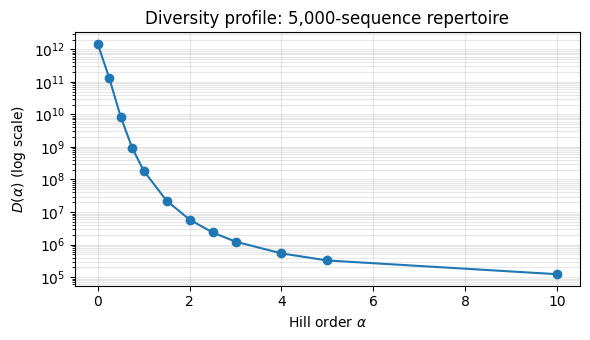

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(curve['orders'], curve['values'], 'o-')
ax.set_xlabel(r'Hill order $\alpha$')
ax.set_ylabel(r'$D(\alpha)$ (log scale)')
ax.set_title(f'Diversity profile: {len(sequences):,d}-sequence repertoire')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


### Summary statistics: `diversity_profile()`

For a one-shot summary the `diversity_profile()` method returns the
four most-used quantities in one dict: entropy in nats, entropy in
bits, effective diversity (`exp(H)`), and uniformity. Uniformity is
$D(1) / D(0)$ and ranges from near-zero (highly skewed) to 1.0
(uniform distribution).


In [7]:
dp = graph.diversity_profile()
print(f'Entropy (nats):      {dp["entropy_nats"]:.4f}')
print(f'Entropy (bits):      {dp["entropy_bits"]:.4f}')
print(f'Effective diversity: {dp["effective_diversity"]:,.0f}')
print(f'Uniformity:          {dp["uniformity"]:.4f}')


Entropy (nats):      19.0614
Entropy (bits):      27.4998
Effective diversity: 189,790,176
Uniformity:          0.0005


## 2. The analytical log-PGEN distribution

`pgen()` gives you the probability of a *specific* sequence. The
*distribution of pgen values across all possible sequences* tells you
the shape of the entire probability landscape. Is it tight around a
typical log-PGEN, or does it span many orders of magnitude? Is it
symmetric or skewed?

`LZGraph` computes the moments of the log-PGEN distribution
analytically via a forward DP and packages the full distribution as a
Gaussian mixture, with one mixture component per LZ76 walk length.


In [8]:
# Moments
m = graph.pgen_moments()
print(f'mean log P:  {m["mean"]:.4f}')
print(f'std:         {m["std"]:.4f}')
print(f'skewness:    {m["skewness"]:.4f}')
print(f'kurtosis:    {m["kurtosis"]:.4f}')
print(f'total mass:  {m["total_mass"]:.6f}')


mean log P:  -20.8304
std:         4.0381
skewness:    -0.5597
kurtosis:    0.3546
total mass:  1.000000


In [9]:
# The full mixture
dist = graph.pgen_distribution()
print(dist)
print(f'Number of mixture components: {dist.n_components}')
print(f'Global mean (matches above):  {dist.mean:.4f}')


PgenDistribution(components=11, mean=-20.8304)
Number of mixture components: 11
Global mean (matches above):  -20.8304


The mixture exposes `pdf()`, `cdf()`, and `sample()` so you can use
it like a scipy distribution. Two means of caution:

- `dist.mean` is the **exact** expected log-PGEN, computed analytically
  over the full forward DP across all walks. Use this when you want
  the true expected value.
- The mean of samples drawn from `dist.sample()` will converge to
  the **mixture's own first moment** ($\sum_i w_i \mu_i$), which is a
  slightly different number because the per-length Gaussian components
  are fit to capture each length's variance, and their weighted
  average doesn't exactly reproduce the global first moment. Treat
  the mixture as a useful approximation of the shape, not as a
  drop-in replacement for the exact moments.

In [10]:
# Sample from the mixture and compare against both the mixture's own
# first moment and the analytical exact mean.
samples = dist.sample(20_000, seed=42)
mixture_first_moment = float((dist.weights * dist.means).sum())

print(f'Sample mean (n=20K):       {samples.mean():.4f}')
print(f'Mixture first moment Σwμ:  {mixture_first_moment:.4f}   (sample mean converges here)')
print(f'Analytical exact mean:     {dist.mean:.4f}   (true expected log-PGEN)')
print()
print(f'Sample std:                {samples.std():.4f}')
print(f'Analytical std:            {m["std"]:.4f}')

Sample mean (n=20K):       -19.0932
Mixture first moment Σwμ:  -19.1242   (sample mean converges here)
Analytical exact mean:     -20.8304   (true expected log-PGEN)

Sample std:                3.3793
Analytical std:            4.0381


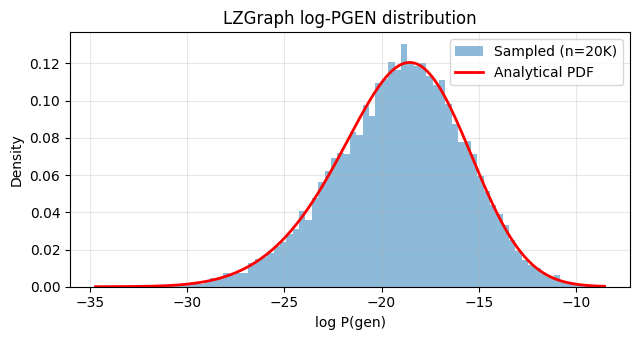

In [11]:
# Visualize: histogram of samples + analytical PDF curve
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(samples, bins=80, density=True, alpha=0.5, label='Sampled (n=20K)')

x = np.linspace(samples.min(), samples.max(), 400)
y = dist.pdf(x)
ax.plot(x, y, 'r-', lw=2, label='Analytical PDF')

ax.set_xlabel('log P(gen)')
ax.set_ylabel('Density')
ax.set_title('LZGraph log-PGEN distribution')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


The mixture is multi-modal because each LZ76 walk length contributes
its own Gaussian (probability mass scales with $1/L$ for walks of
length $L$, so longer walks sit further left on the log axis). Use
the analytical distribution for fast quantile queries and to put a
single sequence in distributional context: a sequence at the 99th
percentile of `cdf` is in the rare tail of the repertoire.


## 3. The occupancy model: predicting unseen samples

You sequenced 5,000 CDR3s and built a graph. How many *distinct*
sequences would you expect to see if you sequenced 100,000 instead?
What's the expected overlap with a second donor who also sequences
50,000? These questions are answered by the **occupancy model**, which
treats each unique sequence as a discrete Poisson event with rate
$\pi(s) \cdot d$ (probability under the model times depth):

$$F(d) = \sum_s \left( 1 - e^{-d \cdot \pi(s)} \right)$$

Two donors at depths $d_1, d_2$ share an expected
$\sum_s (1 - e^{-d_1 \pi(s)})(1 - e^{-d_2 \pi(s)})$ sequences.
Both are computed analytically from the graph in constant time.


In [12]:
# Predicted richness at increasing depth
for depth in [100, 1_000, 10_000, 100_000, 1_000_000]:
    r = graph.predicted_richness(depth)
    print(f'  depth = {depth:>9,d}  →  expected unique = {r:,.1f}')


  depth =       100  →  expected unique = 100.0
  depth =     1,000  →  expected unique = 999.9
  depth =    10,000  →  expected unique = 9,990.4
  depth =   100,000  →  expected unique = 99,142.7


  depth = 1,000,000  →  expected unique = 947,553.3


In [13]:
# Predicted overlap between two donors at the same depth
for depth in [1_000, 10_000, 100_000]:
    o = graph.predicted_overlap(depth, depth)
    print(f'  both donors at depth {depth:>7,d}  →  expected shared = {o:,.2f}')


  both donors at depth   1,000  →  expected shared = 0.19
  both donors at depth  10,000  →  expected shared = 18.65


  both donors at depth 100,000  →  expected shared = 1,438.61


Read the richness curve as a saturation profile: at depth 100 you'll
see almost every sequence as unique (the repertoire is much larger);
at depth 1M, doubling the depth would still recover thousands of new
sequences (the right tail is heavy). The overlap numbers say: even at
100K sequences per donor, the expected pairwise overlap between two
independent draws from this graph is tiny.


## 4. The sharing spectrum across multiple donors

`predict_sharing` extends the occupancy model to $K$ donors. Given
the sequencing depth for each donor, it returns the expected number
of sequences shared by *exactly* 1, 2, ..., $K$ donors. This is
useful for predicting "public" sequences in cohort designs and for
sanity-checking observed sharing against the null model.

The spectrum's compute cost grows quickly with $K$ and graph size, so
in practice you'll often run it on a focused subset of the graph.


In [14]:
# Run on a small subgraph so the demo finishes quickly
small_g = LZGraph(sequences[:200], variant='aap')
sharing = small_g.predict_sharing([200, 200, 200, 200, 200], max_k=5)

print(f'Cohort: 5 donors x 200 sequences each')
print(f'Expected total unique sequences: {sharing["expected_total"]:,.1f}')
print(f'Number of donors:                {sharing["n_donors"]}')
print()
print('Sharing spectrum (expected count of seqs shared by exactly k donors):')
for k, count in enumerate(sharing['spectrum'], 1):
    print(f'  k = {k}  →  {count:.4f}')


Cohort: 5 donors x 200 sequences each
Expected total unique sequences: 328.5
Number of donors:                5

Sharing spectrum (expected count of seqs shared by exactly k donors):
  k = 1  →  327.7454
  k = 2  →  0.7572
  k = 3  →  0.0068
  k = 4  →  0.0001
  k = 5  →  0.0000


## 5. Comparing two repertoires

The two standard ways to compare repertoires under LZGraphs:

- **Jensen-Shannon divergence** is a distributional comparison: how
  different are the probability distributions encoded by the two
  graphs? Computed in nats (natural log), so the range is
  $[0, \ln 2 \approx 0.693]$.
- **Jaccard index over nodes** is a structural comparison: how much
  of the node set of one graph appears in the other? Computed via
  the intersection operator `&`.

The two answers can disagree informatively. Two repertoires can share
most of their LZ76 tokens (high Jaccard) but assign very different
probability mass across them (high JSD), or vice versa.


In [15]:
# Split into two halves and compare
g1 = LZGraph(sequences[:2500], variant='aap')
g2 = LZGraph(sequences[2500:], variant='aap')

jsd_diff = jensen_shannon_divergence(g1, g2)
jsd_self = jensen_shannon_divergence(g1, g1)
print(f'JSD(half1, half2): {jsd_diff:.6f}')
print(f'JSD(half1, half1): {jsd_self:.6f}  (sanity check, should be 0.0)')


JSD(half1, half2): 0.016957
JSD(half1, half1): 0.000000  (sanity check, should be 0.0)


In [16]:
# Structural overlap via intersection
inter = g1 & g2
s1, s2, si = g1.summary(), g2.summary(), inter.summary()
jaccard_nodes = si['n_nodes'] / (s1['n_nodes'] + s2['n_nodes'] - si['n_nodes'])
jaccard_edges = si['n_edges'] / (s1['n_edges'] + s2['n_edges'] - si['n_edges'])
print(f'half1 nodes={s1["n_nodes"]:,d}  half2 nodes={s2["n_nodes"]:,d}')
print(f'shared nodes={si["n_nodes"]:,d}  shared edges={si["n_edges"]:,d}')
print(f'Jaccard (nodes): {jaccard_nodes:.4f}')
print(f'Jaccard (edges): {jaccard_edges:.4f}')


half1 nodes=1,355  half2 nodes=1,338
shared nodes=823  shared edges=3,033
Jaccard (nodes): 0.4401
Jaccard (edges): 0.3145


## 6. Per-sequence model fit: perplexity and entropy rate

Where Hill numbers measure the *width* of the distribution, perplexity
measures how *surprising* an individual sequence (or a held-out batch
of sequences) is to the model. It's defined as
$\text{perplexity}(s) = \exp(-\frac{1}{|s|} \log P(s))$, the
geometric mean of the per-token branching factor along the walk.

Three flavors:

- `sequence_perplexity(s)`: scalar per-sequence value
- `repertoire_perplexity([s1, s2, ...])`: aggregate over a batch
- `path_entropy_rate([s1, s2, ...])`: token-level entropy, the
  expected $-\log P$ per token

Lower perplexity = better model fit. Repertoire perplexity below the
naive uniform baseline (=alphabet size) means the model has learned
some structure.


In [17]:
for s in sequences[:5]:
    pp = graph.sequence_perplexity(s)
    print(f'{s:<25}  perplexity = {pp:.3f}')


CASSGLAGSRSYNEQFF          perplexity = 5.567
CASSPTGGVYEQYF             perplexity = 3.860
CASSQTGESNQPQHF            perplexity = 3.689
CASSKTDISSPLHF             perplexity = 8.060
CASSLAGHSGGAQRGNEQFF       perplexity = 4.425


In [18]:
# Aggregate over a held-out batch
heldout = sequences[-500:]
rep_pp  = graph.repertoire_perplexity(heldout)
ent_rate = graph.path_entropy_rate(heldout)
print(f'Held-out repertoire perplexity ({len(heldout)} seqs): {rep_pp:.3f}')
print(f'Entropy rate (bits per token):                       {ent_rate:.4f}')


Held-out repertoire perplexity (500 seqs): 4.893
Entropy rate (bits per token):                       2.2907


## 7. Utilities that bypass the graph object

`k_diversity` and `saturation_curve` are top-level package functions
that operate directly on raw sequence lists. They are useful when you
want a quick diversity number or a saturation profile without paying
to build the full `LZGraph` first.

- `k_diversity(seqs, k, draws, ...)`: bootstrap richness at sample
  size $k$, reporting mean / std / 95% CI across `draws` resamples
- `saturation_curve(seqs, log_every, ...)`: as you walk through the
  input list, how do node and edge counts grow?


In [19]:
kd = k_diversity(sequences, k=100, variant='aap', draws=50, seed=42)
print(f'k_diversity(k=100, 50 bootstrap draws):')
print(f'  mean = {kd["mean"]:.2f}')
print(f'  std  = {kd["std"]:.2f}')
print(f'  95%  = [{kd["ci_low"]:.2f}, {kd["ci_high"]:.2f}]')


k_diversity(k=100, 50 bootstrap draws):
  mean = 106.44
  std  = 4.80
  95%  = [105.11, 107.77]


In [20]:
sat = saturation_curve(sequences, variant='aap', log_every=500)
print('n_sequences  n_nodes   n_edges')
for p in sat:
    print(f'  {p["n_sequences"]:>5,d}     {p["n_nodes"]:>5,d}     {p["n_edges"]:>5,d}')


n_sequences  n_nodes   n_edges
    500       753     2,269
  1,000       997     3,585
  1,500     1,149     4,640
  2,000     1,262     5,529
  2,500     1,355     6,384
  3,000     1,446     7,163
  3,500     1,526     7,844
  4,000     1,582     8,463
  4,500     1,648     9,101
  5,000     1,721     9,644


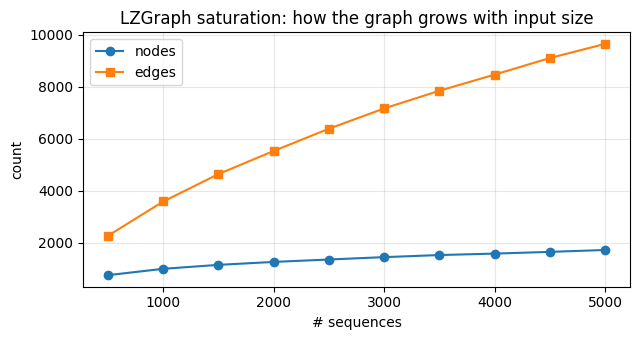

In [21]:
# Plot the saturation curve
ns = [p['n_sequences'] for p in sat]
nodes = [p['n_nodes'] for p in sat]
edges = [p['n_edges'] for p in sat]

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(ns, nodes, 'o-', label='nodes')
ax.plot(ns, edges, 's-', label='edges')
ax.set_xlabel('# sequences')
ax.set_ylabel('count')
ax.set_title('LZGraph saturation: how the graph grows with input size')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


The flattening of the nodes curve at large $n$ is the diminishing-
returns signal: each new sequence introduces fewer novel tokens. Edge
counts continue growing roughly linearly with the number of
sequences, because each sequence still contributes its own walk.


## What you learned

You can now:

- Quantify diversity at any Hill order using `hill_number` /
  `hill_numbers` / `hill_curve`, and recover exact richness from
  `path_count`
- Summarize a repertoire's distribution with `diversity_profile()`
- Build the analytical log-PGEN distribution and sample / query it
  like a scipy continuous distribution
- Predict unseen-sample richness, overlap, and the K-donor sharing
  spectrum using the occupancy model
- Compare two repertoires distributionally (`jensen_shannon_divergence`)
  and structurally (`&` operator over graphs)
- Score sequences and held-out batches with perplexity and entropy rate
- Get fast diversity estimates and saturation profiles from raw
  sequence lists with `k_diversity` and `saturation_curve`

**Next:** Lesson 3 (`03_Advanced_Usage.ipynb`) covers what to do with
*two or more* graphs: union / intersection / difference, weighted
merge, Bayesian posterior updates for personalization, and the ML
feature extraction interface used in classification pipelines.
